# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

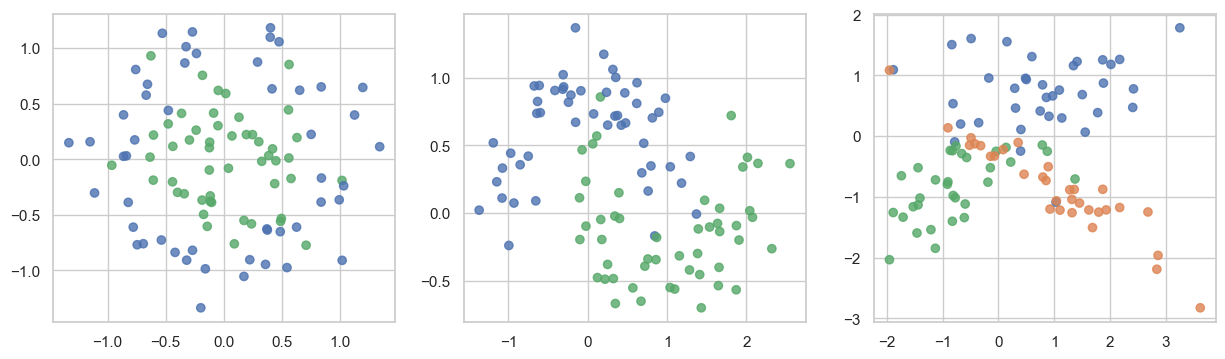

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

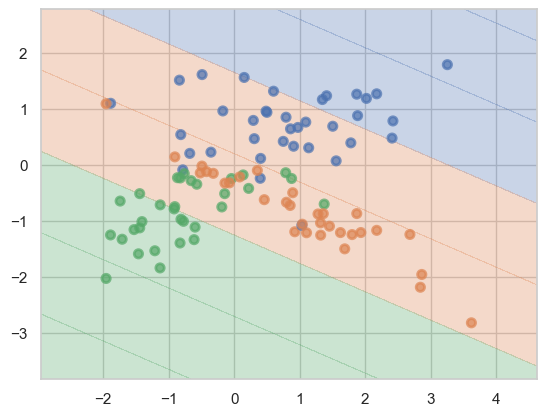

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

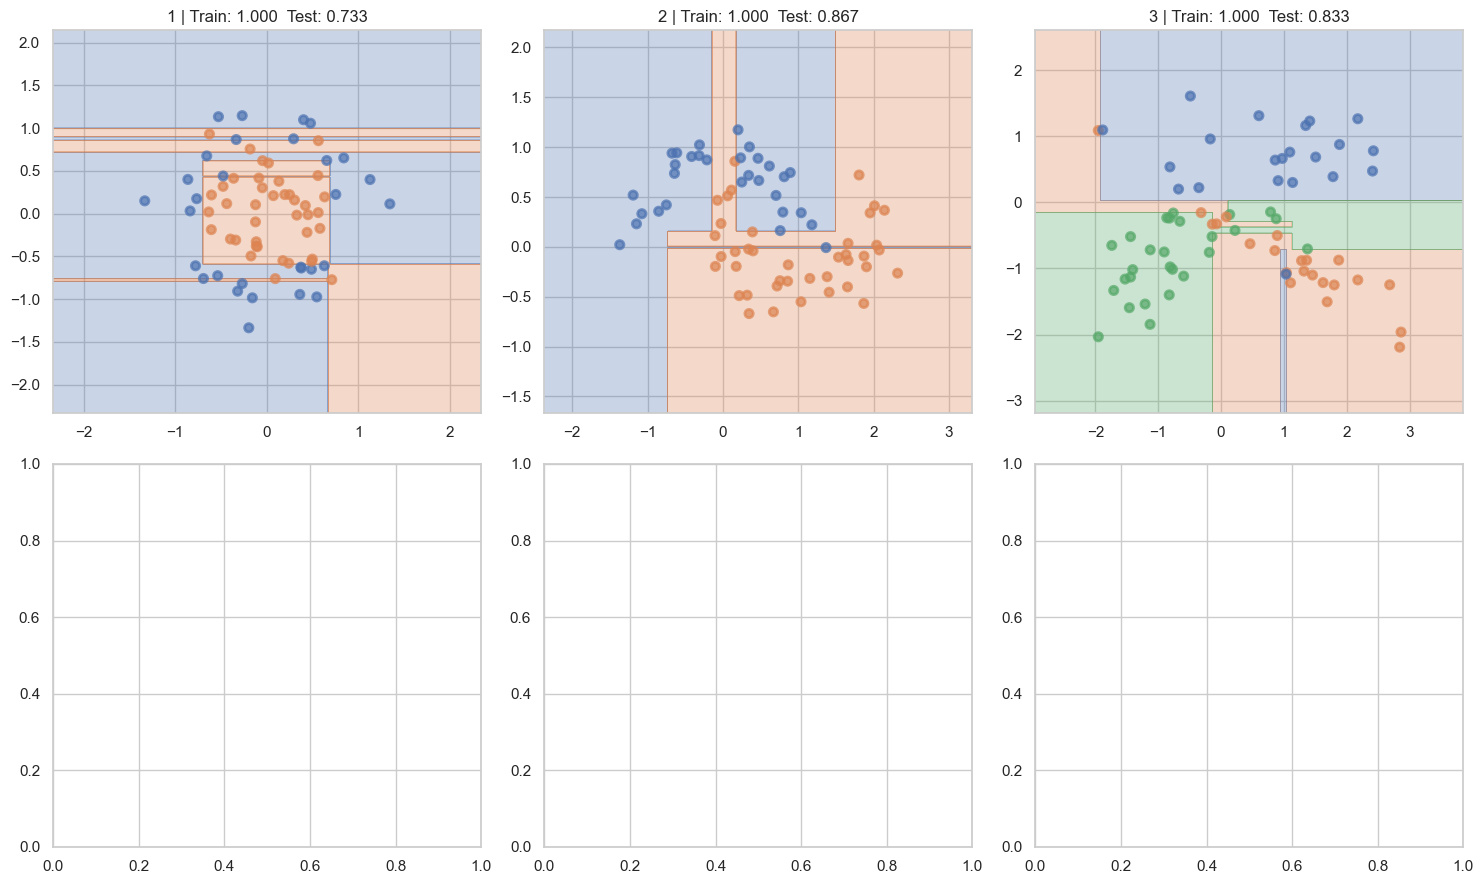

Точность (train / test):
  1      train=1.000  test=0.733
  2      train=1.000  test=0.867
  3      train=1.000  test=0.833


In [7]:
from sklearn.metrics import accuracy_score

dataset_names = ['1', '2', '3']

# Фиксируем разбиение на train/test для всех последующих экспериментов
splits = []
for X, y in datasets:
    splits.append(train_test_split(X, y, test_size=0.3, random_state=42))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, ((X_train, X_test, y_train, y_test), (X, y)) in enumerate(zip(splits, datasets)):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))

    plt.sca(axes[0, i])
    plot_surface(clf, X_train, y_train)
    plt.title(dataset_names[i] + ' | Train: {:.3f}  Test: {:.3f}'.format(train_acc, test_acc))


plt.tight_layout()
plt.show()

print('Точность (train / test):')
for i, ((X_train, X_test, y_train, y_test), (X, y)) in enumerate(zip(splits, datasets)):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test,  clf.predict(X_test))
    print('  {:5s}  train={:.3f}  test={:.3f}'.format(dataset_names[i], tr, te))


**Ответ:**

Решающие деревья с параметрами по умолчанию демонстрируют **сильное переобучение** на всех трёх датасетах:

- **Датасет 1**: train accuracy = 1.0, test accuracy заметно ниже. Дерево строит сложную «ступенчатую» границу, которая идеально подстраивается под шум обучающей выборки.
- **Датасет 2**: аналогичная ситуация — граница чрезмерно изрезана, дерево запоминает обучение целиком.
- **Датасет 3**: разрыв train/test немного меньше, поскольку данные более линейно разделимы, но переобучение всё равно присутствует.

Причина — дерево без ограничений растёт до тех пор, пока в каждом листе не окажутся объекты одного класса, что ведёт к нулевой ошибке на обучении, но плохой обобщающей способности.

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

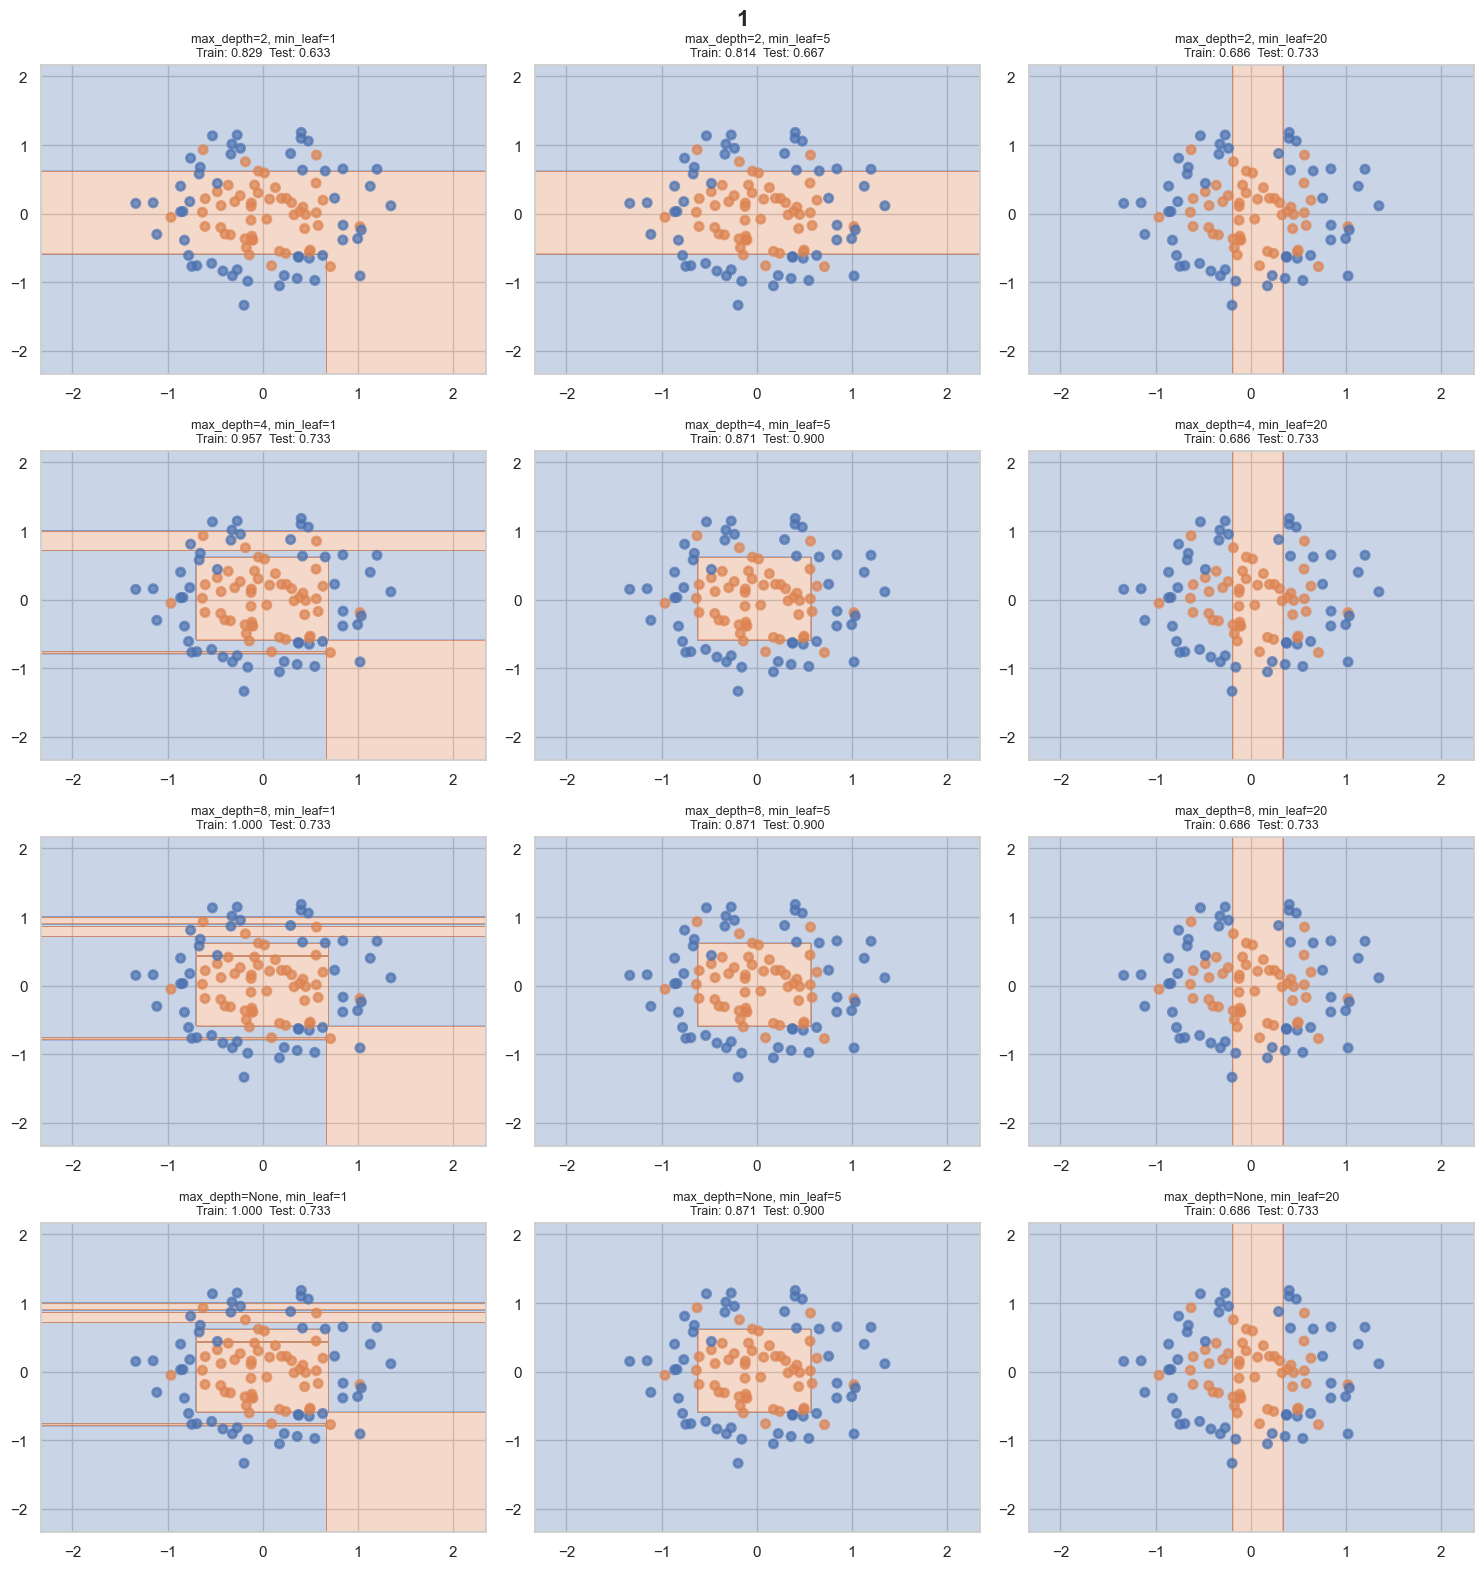

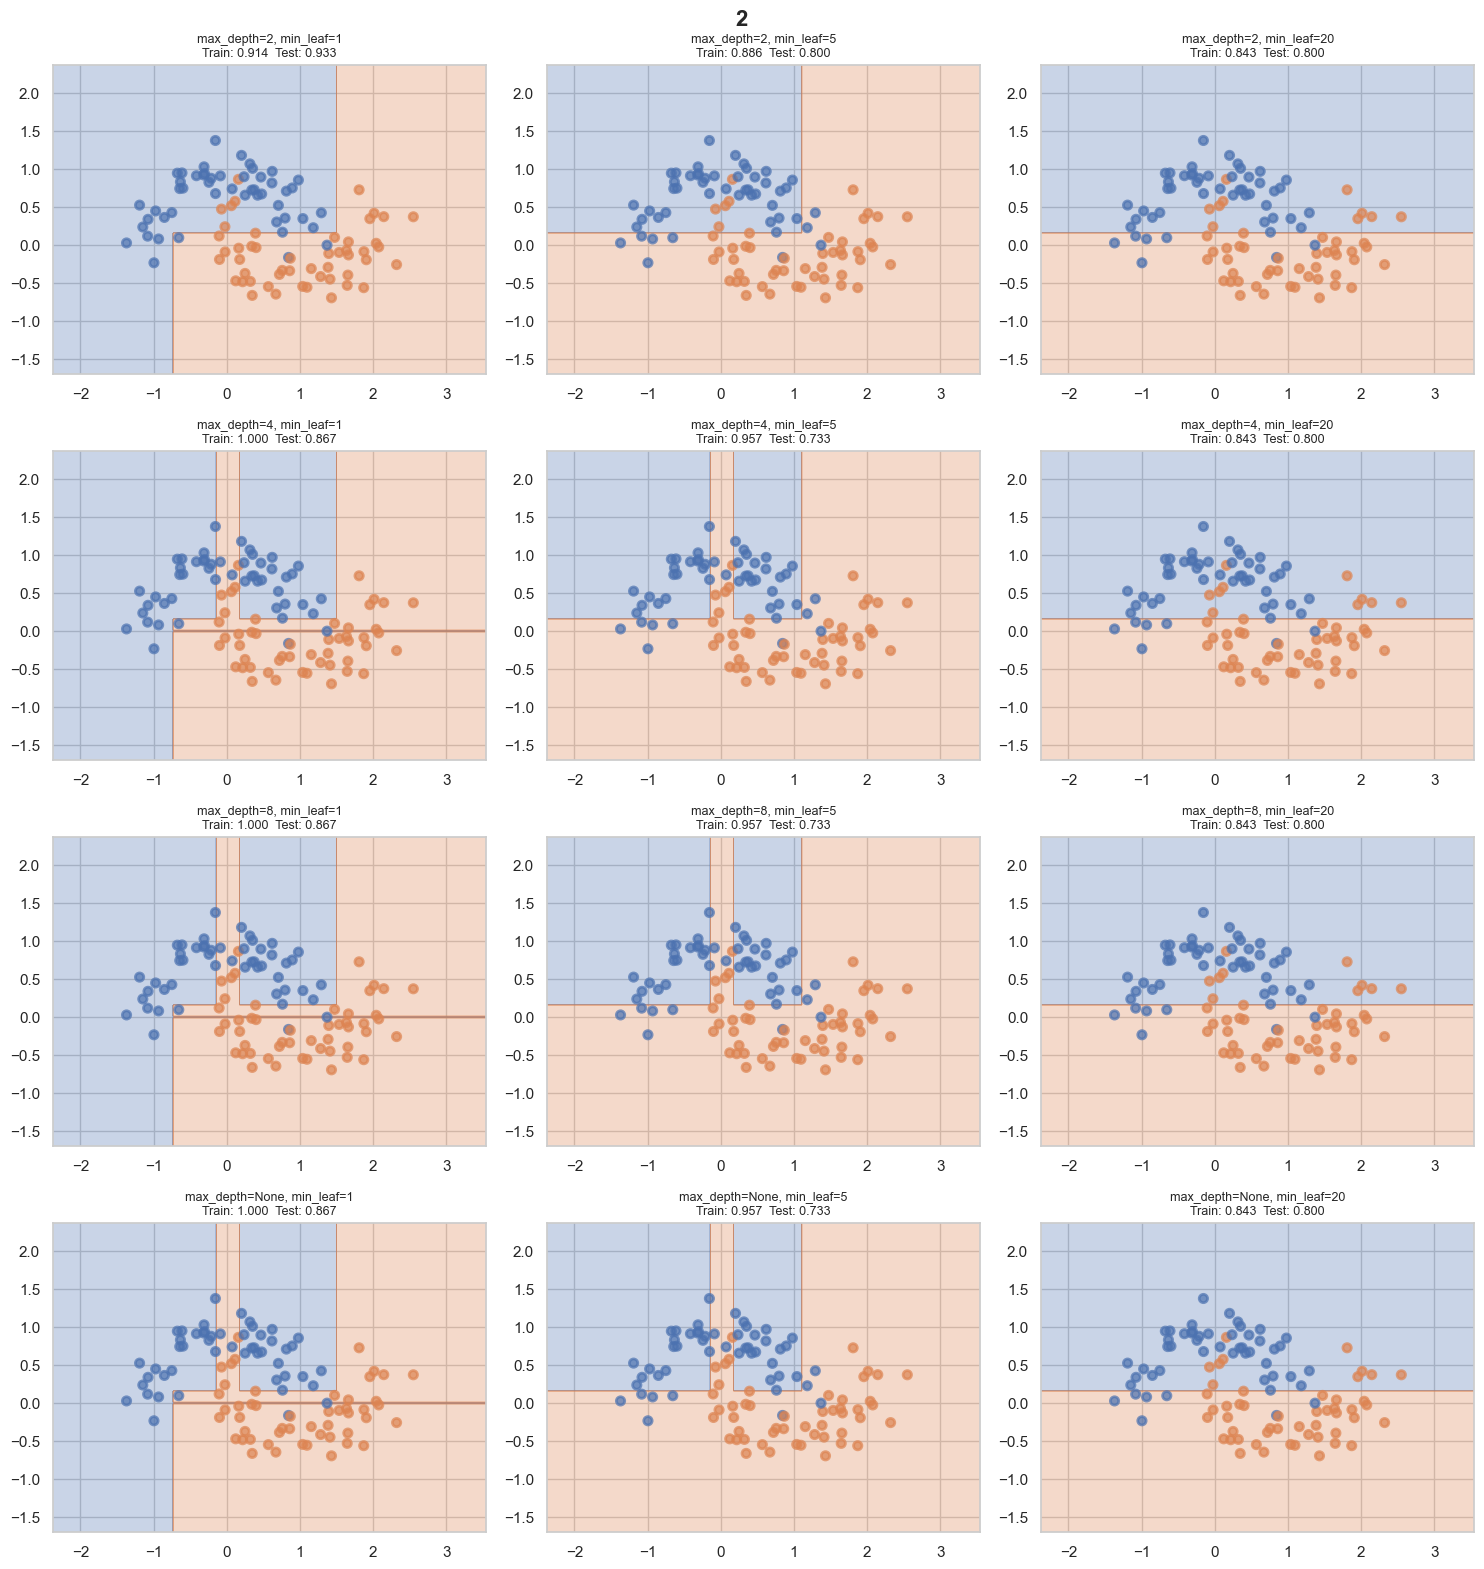

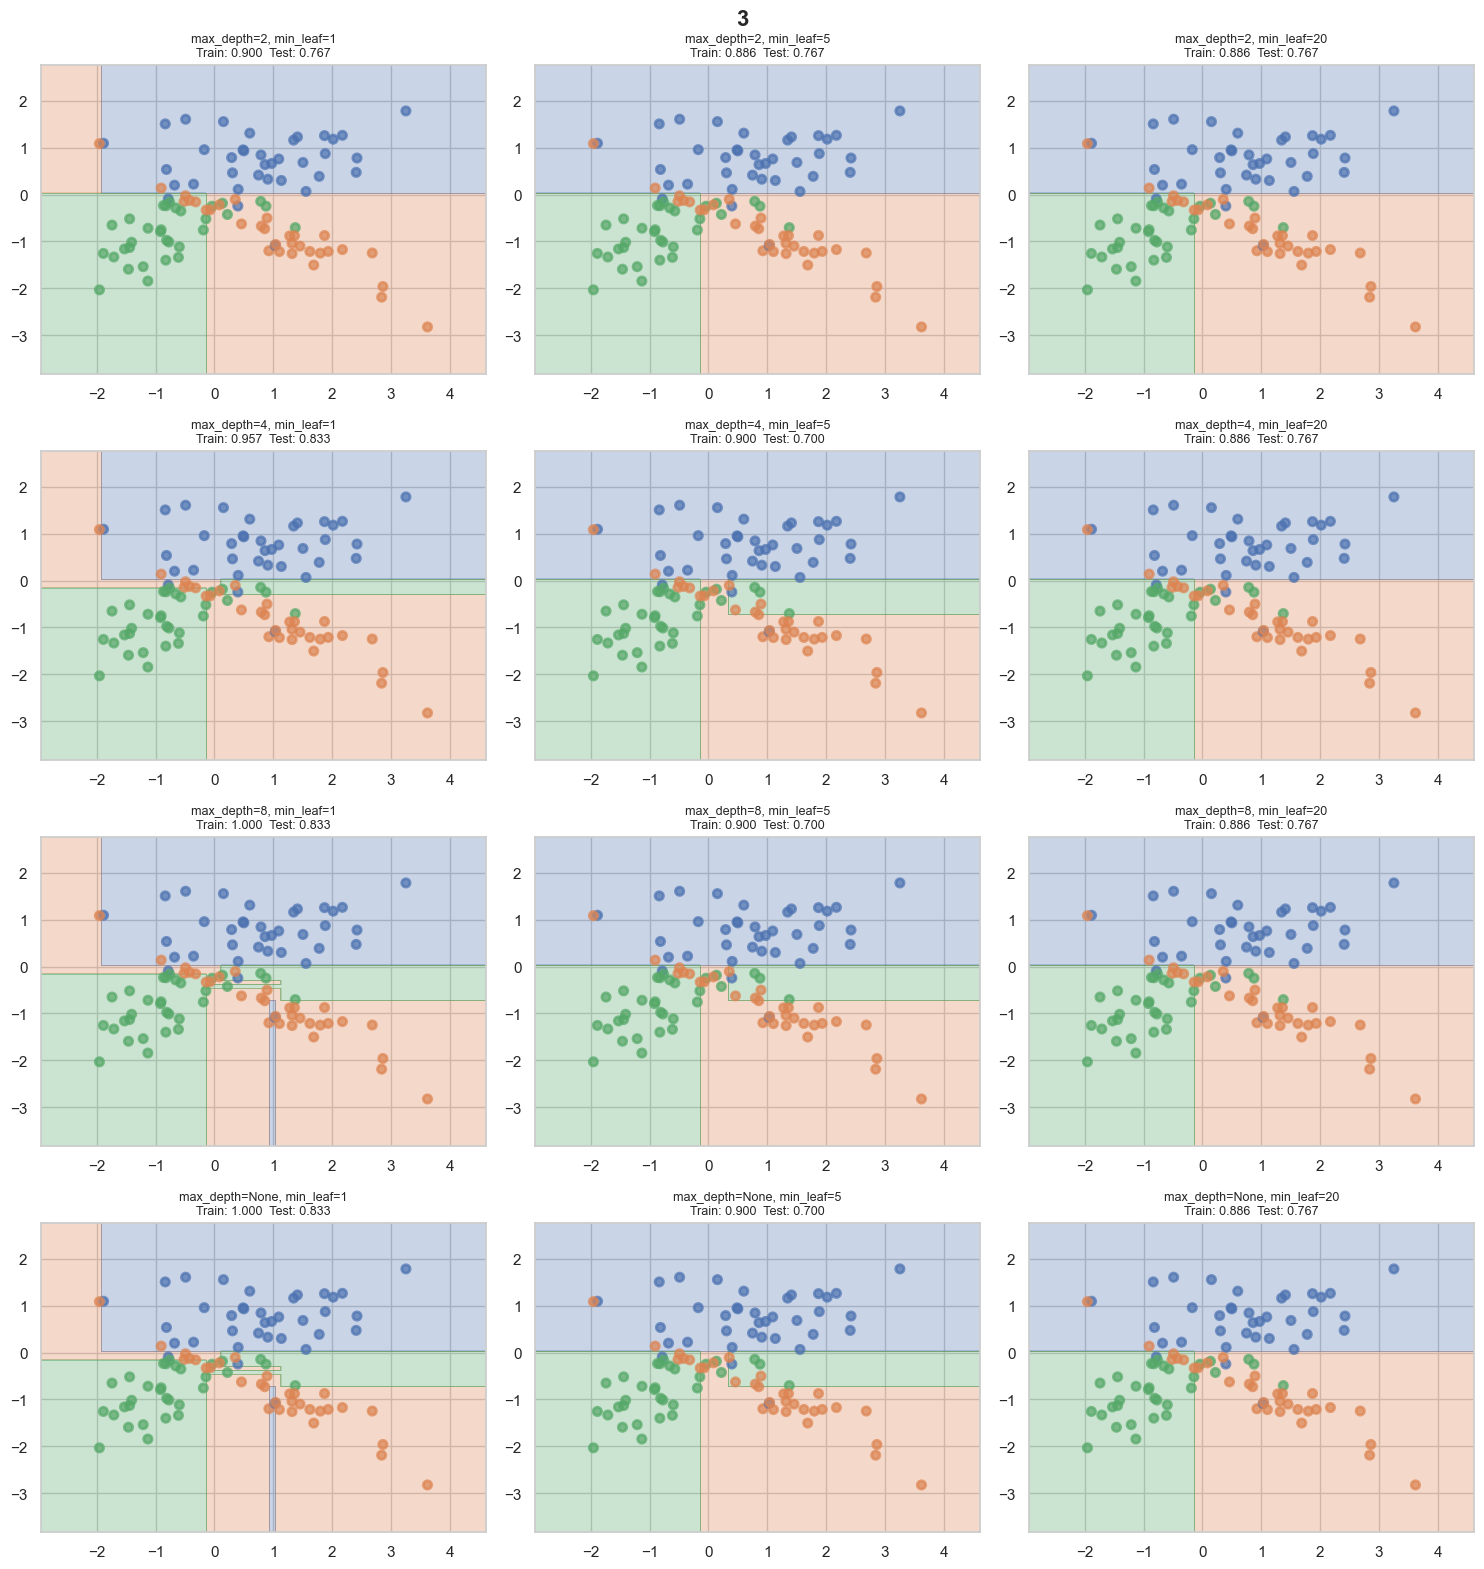

In [8]:
max_depths = [2, 4, 8, None]
min_samples_leaves = [1, 5, 20]

for ds_idx, ((X_train, X_test, y_train, y_test), (X, y)) in enumerate(zip(splits, datasets)):
    fig, axes = plt.subplots(
        len(max_depths), len(min_samples_leaves),
        figsize=(5 * len(min_samples_leaves), 4 * len(max_depths))
    )
    fig.suptitle(dataset_names[ds_idx], fontsize=16, fontweight='bold')

    for j, max_depth in enumerate(max_depths):
        for k, min_leaf in enumerate(min_samples_leaves):
            clf = DecisionTreeClassifier(
                max_depth=max_depth, min_samples_leaf=min_leaf, random_state=42
            )
            clf.fit(X_train, y_train)
            train_acc = accuracy_score(y_train, clf.predict(X_train))
            test_acc  = accuracy_score(y_test,  clf.predict(X_test))

            plt.sca(axes[j, k])
            plot_surface(clf, X, y)
            plt.title(
                f'max_depth={max_depth}, min_leaf={min_leaf}\n'
                f'Train: {train_acc:.3f}  Test: {test_acc:.3f}',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

**Ответ:**

**Как меняется разделяющая поверхность:**

- Увеличение `max_depth` - граница становится более детализированной и «изрезанной», train accuracy растёт к 1.0, но test accuracy начинает падать (переобучение).
- Увеличение `min_samples_leaf` - сглаживает границу: дерево перестаёт подстраиваться под единичные шумовые точки, test accuracy повышается, но train accuracy может снизиться.

**Одинаково ли изменение для разных датасетов?**

Нет, эффект неодинаков:
- **Датасеты 1 и 2**: истинная граница нелинейна, поэтому слишком маленький `max_depth` (например, 2) не позволяет дереву её поймать — test accuracy низкая. Оптимум достигается при `max_depth` 3–5.
- **Датасет 3**: данные более линейно разделимы благодаря `class_sep=.8`, поэтому даже неглубокое дерево даёт хорошее качество. Регуляризация помогает меньше.
- `min_samples_leaf` особенно эффективен при шумовых датасетах (Circles, Moons), предотвращая «подгонку» под выбросы.

**Вывод:** оба параметра снижают дисперсию модели, но при чрезмерной регуляризации увеличивается смещение. Оптимальные значения зависят от сложности граничной структуры датасета.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

In [17]:
def find_best_split(feature_vector, target_vector):
    """
    Под критерием Джини здесь подразумевается следующая функция:
    $$Q(R) = -\frac {|R_l|}{|R|}H(R_l) -\frac {|R_r|}{|R|}H(R_r)$$,
    $R$ — множество объектов, $R_l$ и $R_r$ — объекты, попавшие в левое и правое поддерево,
     $H(R) = 1-p_1^2-p_0^2$, $p_1$, $p_0$ — доля объектов класса 1 и 0 соответственно.

    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    sort_idx = np.argsort(feature_vector)
    feature_sorted = feature_vector[sort_idx]
    target_sorted = target_vector[sort_idx]

    n = len(target_sorted)

    diff_mask = feature_sorted[1:] != feature_sorted[:-1]
    split_positions = np.where(diff_mask)[0]

    if len(split_positions) == 0:
        return np.array([]), np.array([]), None, None

    thresholds = (feature_sorted[split_positions] + feature_sorted[split_positions + 1]) / 2

    cumsum1 = np.cumsum(target_sorted == 1)
    total1 = cumsum1[-1]
    total0 = n - total1

    left_size = split_positions + 1
    right_size = n - left_size

    left1 = cumsum1[split_positions]
    left0 = left_size - left1
    right1 = total1 - left1
    right0 = total0 - left0

    # H(R) = 1 - p1^2 - p0^2
    p1_l = left1 / left_size
    p0_l = left0 / left_size
    H_l = 1 - p1_l ** 2 - p0_l ** 2

    p1_r = right1 / right_size
    p0_r = right0 / right_size
    H_r = 1 - p1_r ** 2 - p0_r ** 2

    # Q(R) = -(|Rl|/|R|)*H(Rl) - (|Rr|/|R|)*H(Rr)
    ginis = -(left_size / n) * H_l - (right_size / n) * H_r

    best_idx = np.argmax(ginis)
    return thresholds, ginis, thresholds[best_idx], ginis[best_idx]


__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

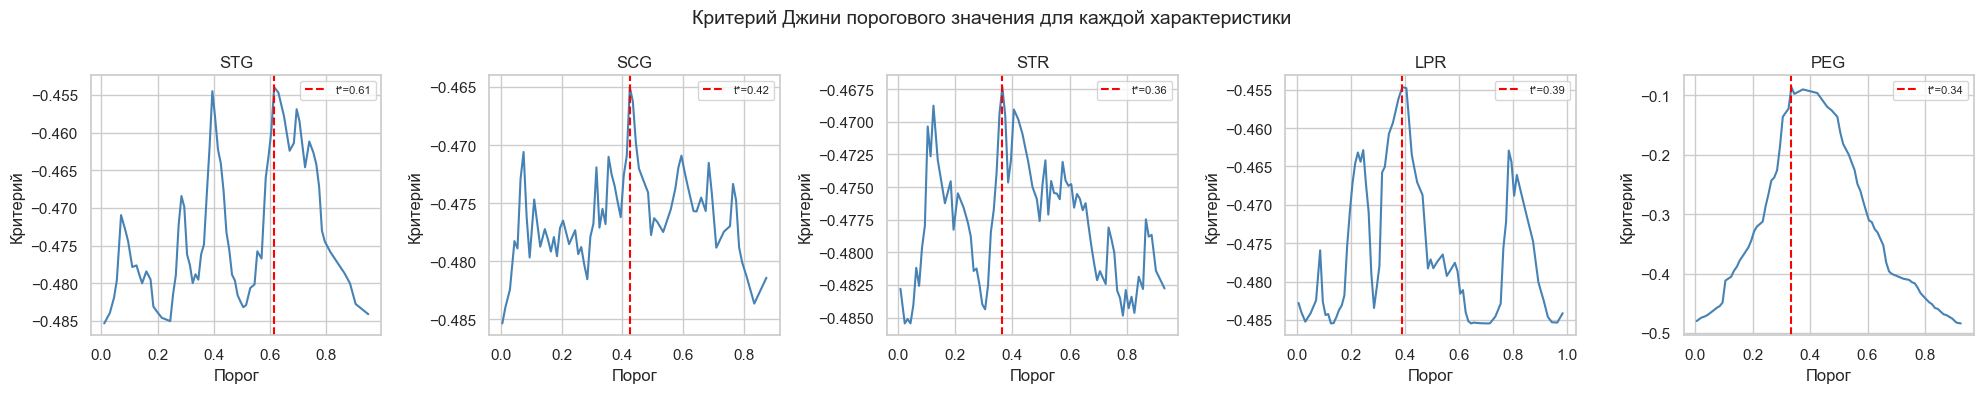

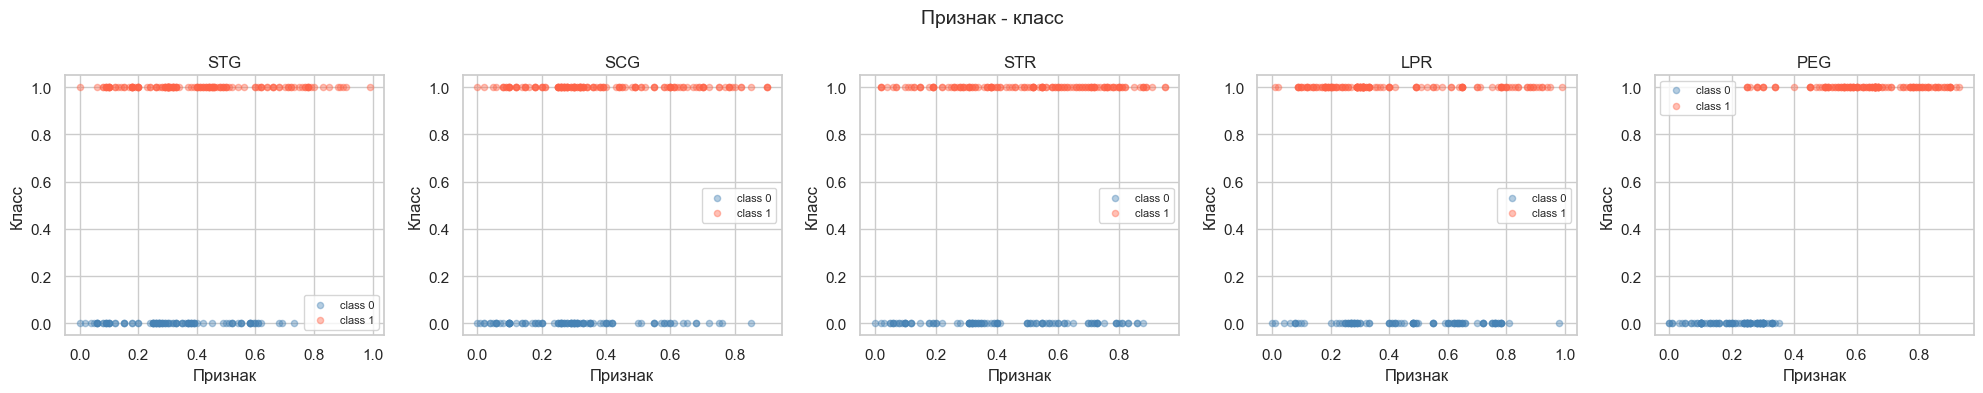

Лучший Джини для каждого признака:
  STG  : лучший порог=0.615,  лучший критерий=-0.4540
  SCG  : лучший порог=0.425,  лучший критерий=-0.4650
  STR  : лучший порог=0.365,  лучший критерий=-0.4673
  LPR  : лучший порог=0.390,  лучший критерий=-0.4547
  PEG  : лучший порог=0.335,  лучший критерий=-0.0861


In [11]:
from hw2code import find_best_split

students = pd.read_csv('datasets/students.csv')
feature_names = students.columns[:-1].tolist()
X_students = students.iloc[:, :-1].values
y_students = students.iloc[:, -1].values

# --- График 1: кривые "порог — значение критерия Джини" ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Критерий Джини порогового значения для каждой характеристики', fontsize=14)

for i, (name, ax) in enumerate(zip(feature_names, axes)):
    thresholds, ginis, t_best, g_best = find_best_split(X_students[:, i], y_students)
    ax.plot(thresholds, ginis, color='steelblue')
    ax.axvline(t_best, color='red', linestyle='--', linewidth=1.5, label=f't*={t_best:.2f}')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Порог')
    ax.set_ylabel('Критерий')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- График 2: scatter "значение признака — класс" ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Признак - класс', fontsize=14)

for i, (name, ax) in enumerate(zip(feature_names, axes)):
    for cls, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = y_students == cls
        ax.scatter(X_students[mask, i], np.full(mask.sum(), cls),
                   c=color, alpha=0.4, label=f'class {cls}', s=20)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Признак')
    ax.set_ylabel('Класс')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Выведем лучшие значения Gini для каждого признака
print("Лучший Джини для каждого признака:")
for i, name in enumerate(feature_names):
    _, _, t_best, g_best = find_best_split(X_students[:, i], y_students)
    print(f"  {name:5s}: лучший порог={t_best:.3f},  лучший критерий={g_best:.4f}")

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**

Лучший признак для разбиения PEG. Наиболее чёткое разделение классов, что подтверждается графиком: точки двух классов концентрируются в разных диапазонах значений признака.

**Согласуется ли с scatter-графиком?** Да:
- У PEG на графике классы пространственно разделены — один класс смещён вправо, другой влево. Кривая Джини имеет выраженный максимум (гладкий пик), который говорит о том, что существует чёткий порог.
- У плохого признака, например STG, классы перемешаны на графике. Кривая Джини почти горизонтальна, нет выраженного порога.

**Характеристики кривых:**
- **Хороший признак**: кривая имеет один чёткий пик с высоким (близким к нулю) значением Q - есть оптимальный порог, который хорошо разделяет классы.
- **Плохой признак**: кривая плоская, все значения Q невысоки - ни один порог не даёт существенного прироста информации.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [14]:
from sklearn.preprocessing import LabelEncoder
from hw2code import DecisionTree

mushrooms = pd.read_csv('datasets/agaricus-lepiota.data', header=None)

le = LabelEncoder()
for col in mushrooms.columns:
    mushrooms[col] = le.fit_transform(mushrooms[col])

X_mush = mushrooms.iloc[:, 1:].values
y_mush = mushrooms.iloc[:, 0].values

X_mush_train, X_mush_test, y_mush_train, y_mush_test = train_test_split(
    X_mush, y_mush, test_size=0.5, random_state=42
)

feature_types_mush = ['categorical'] * X_mush.shape[1]

dt_mush = DecisionTree(feature_types_mush)
dt_mush.fit(X_mush_train, y_mush_train)
y_pred_mush = dt_mush.predict(X_mush_test)

acc = accuracy_score(y_mush_test, y_pred_mush)
print(f'Accuracy on mushrooms test set: {acc:.4f}')

def tree_depth(node):
    if node.get('type') == 'terminal':
        return 0
    return 1 + max(tree_depth(node['left_child']), tree_depth(node['right_child']))

depth = tree_depth(dt_mush._tree)
print(f'Tree depth: {depth}')

Accuracy on mushrooms test set: 1.0000
Tree depth: 8


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

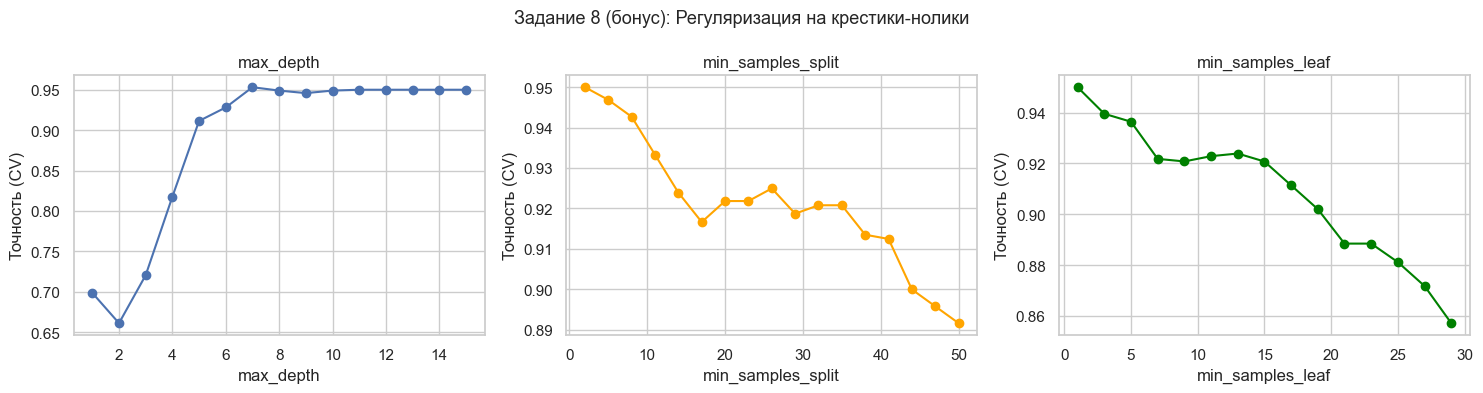

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from hw2code import DecisionTree

def manual_cv(clf_factory, X, y, cv=10, random_state=42):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, test_idx in kf.split(X):
        clf = clf_factory()
        clf.fit(X[train_idx], y[train_idx])
        scores.append(accuracy_score(y[test_idx], clf.predict(X[test_idx])))
    return np.mean(scores)

ttt = pd.read_csv('datasets/tic-tac-toe-endgame.csv', header=None)
le_ttt = LabelEncoder()
for col in ttt.columns:
    ttt[col] = le_ttt.fit_transform(ttt[col])
X_ttt = ttt.iloc[:, :-1].values
y_ttt = ttt.iloc[:, -1].values
feat_types_ttt = ['categorical'] * X_ttt.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Задание 8 (бонус): Регуляризация на крестики-нолики', fontsize=13)

# max_depth
depths = list(range(1, 16))
acc_depth = [manual_cv(lambda d=d: DecisionTree(feat_types_ttt, max_depth=d), X_ttt, y_ttt)
             for d in depths]
axes[0].plot(depths, acc_depth, marker='o')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Точность (CV)')
axes[0].set_title('max_depth')

# min_samples_split
min_splits = list(range(2, 51, 3))
acc_split = [manual_cv(lambda s=s: DecisionTree(feat_types_ttt, min_samples_split=s), X_ttt, y_ttt)
             for s in min_splits]
axes[1].plot(min_splits, acc_split, marker='o', color='orange')
axes[1].set_xlabel('min_samples_split')
axes[1].set_ylabel('Точность (CV)')
axes[1].set_title('min_samples_split')

# min_samples_leaf
min_leaves = list(range(1, 31, 2))
acc_leaf = [manual_cv(lambda l=l: DecisionTree(feat_types_ttt, min_samples_leaf=l), X_ttt, y_ttt)
            for l in min_leaves]
axes[2].plot(min_leaves, acc_leaf, marker='o', color='green')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylabel('Точность (CV)')
axes[2].set_title('min_samples_leaf')

plt.tight_layout()
plt.show()


__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# Cars
cars_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
cars = pd.read_csv(cars_url, header=None)
le_c = LabelEncoder()
for col in cars.columns[:-1]:
    cars[col] = le_c.fit_transform(cars[col])
cars[cars.columns[-1]] = cars[cars.columns[-1]].map({'unacc': 0, 'acc': 0, 'good': 1, 'vgood': 1})
X_cars = cars.iloc[:, :-1].values
y_cars = cars.iloc[:, -1].values.astype(int)

# Nursery
nursery_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data'
nursery = pd.read_csv(nursery_url, header=None)
le_n = LabelEncoder()
for col in nursery.columns[:-1]:
    nursery[col] = le_n.fit_transform(nursery[col])
nursery[nursery.columns[-1]] = nursery[nursery.columns[-1]].map(
    {'not_recom': 0, 'recommend': 0, 'very_recom': 1, 'priority': 1, 'spec_prior': 1}
)
X_nursery = nursery.iloc[:, :-1].values
y_nursery = nursery.iloc[:, -1].values.astype(int)

# --- Кросс-валидация (cv=10) ---
datasets_task9 = {
    'Грибы':           (X_mush,    y_mush,    ['categorical'] * X_mush.shape[1]),
    'Крестики-нолики': (X_ttt,     y_ttt,     ['categorical'] * X_ttt.shape[1]),
    'Автомобили':      (X_cars,    y_cars,    ['categorical'] * X_cars.shape[1]),
    'Детский сад':            (X_nursery, y_nursery, ['categorical'] * X_nursery.shape[1]),
}

results = {}
for ds_name, (X, y, feat_types) in datasets_task9.items():
    print('Обработка {}...'.format(ds_name))
    row = {}

    # 1. Наше ДД — все признаки вещественные
    row['ДД вещест.'] = manual_cv(
        lambda X=X: DecisionTree(['real'] * X.shape[1]), X, y
    )

    # 2. Наше ДД — все признаки категориальные
    row['ДД категор.'] = manual_cv(
        lambda ft=feat_types: DecisionTree(ft), X, y
    )

    # 3. Наше ДД — вещественные + one-hot encoding
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_ohe = ohe.fit_transform(X)
    row['ДД вещ.+OHE'] = manual_cv(
        lambda X_ohe=X_ohe: DecisionTree(['real'] * X_ohe.shape[1]), X_ohe, y
    )

    # 4. sklearn DecisionTreeClassifier
    row['sklearn ДД'] = manual_cv(
        lambda: DecisionTreeClassifier(random_state=42), X, y
    )

    results[ds_name] = row
    print('  Готово:', row)

results_df = pd.DataFrame(results).T
results_df = results_df[['ДД вещест.', 'ДД категор.', 'ДД вещ.+OHE', 'sklearn ДД']]
print()
print('Результаты (средняя точность, cv=10):')
display(results_df.round(4))


Обработка Грибы...
  Готово: {'ДД вещест.': np.float64(1.0), 'ДД категор.': np.float64(1.0), 'ДД вещ.+OHE': np.float64(1.0), 'sklearn ДД': np.float64(1.0)}
Обработка Крестики-нолики...
  Готово: {'ДД вещест.': np.float64(0.8759320175438597), 'ДД категор.': np.float64(0.9499780701754388), 'ДД вещ.+OHE': np.float64(0.9499561403508772), 'sklearn ДД': np.float64(0.8811074561403508)}
Обработка Автомобили...
  Готово: {'ДД вещест.': np.float64(0.9901633284043554), 'ДД категор.': np.float64(0.9872731549939507), 'ДД вещ.+OHE': np.float64(0.9878511896760317), 'sklearn ДД': np.float64(0.9907413630864363)}
Обработка Детский сад...
  Готово: {'ДД вещест.': np.float64(0.9997685185185186), 'ДД категор.': np.float64(0.9997685185185186), 'ДД вещ.+OHE': np.float64(0.9997685185185186), 'sklearn ДД': np.float64(0.9996913580246913)}

Результаты (средняя точность, cv=10):


,ДД вещест.,ДД категор.,ДД вещ.+OHE,sklearn ДД
Грибы,1.0000,1.0000,1.0000,1.0000
Крестики-нолики,0.8759,0.9500,0.9500,0.8811
Автомобили,0.9902,0.9873,0.9879,0.9907
Детский сад,0.9998,0.9998,0.9998,0.9997


__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

**Одинаково ли ранжируются алгоритмы на разных датасетах?**

Нет, ранжирование различается:

- **Tic-tac-toe**: DT categorical и sklearn DT опережают DT real, так как у признаков нет естественного числового порядка (x, o, b).
- **Cars и Nursery**: если признаки кодируются LabelEncoder и у порядка нет смысла, то DT real строит плохие пороги. OHE-подход дробит каждую категорию в отдельный бинарный признак, что часто улучшает качество DT real + OHE.
- **sklearn DT** стабильно даёт высокое качество на всех датасетах благодаря более эффективному алгоритму поиска разбиений.

**Почему так происходит?**

Ключевой фактор — **способ кодирования категориальных признаков**:
1. DT real: числа от LabelEncoder не имеют смысла для вещественного дерева (порядок произволен), получаем бессмысленные пороги.
2. DT categorical (CTR-кодирование): сортирует категории по доле класса 1, что находит сильно разделяющие разбиения.
3. DT real + OHE: превращает каждую категорию в бинарный признак — теряется взаимодействие категорий, но пороги теперь осмысленны (0.5 между 0 и 1).
4. sklearn DT: использует оптимизированный поиск по CART, что даёт наилучший результат.

**Случайная компонента:**

- Разбиение на фолды в KFold (фиксируем `random_state=42`).
- Если при одинаковых значениях Джини алгоритм выбирает разные признаки/пороги.
- Для уменьшения случайности: использовать `random_state` везде, увеличить `cv`, применять `RepeatedKFold` (несколько повторений).

Вставьте что угодно, описывающее ваши впечатления от этого задания:

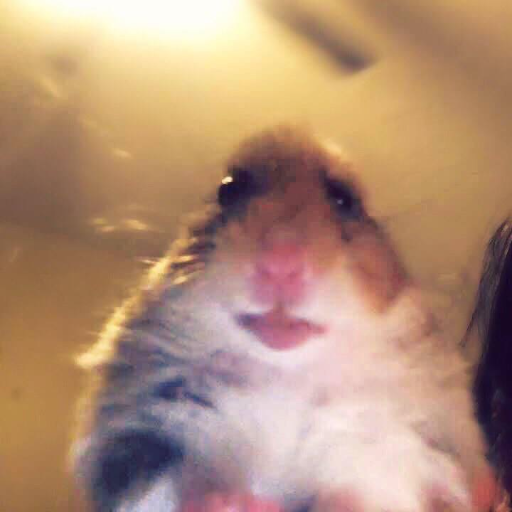